In [7]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import os
import pickle

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from adaptive_smc.save_and_read_and_postprocess import acf


PKLs = []
PKL_titles = []
DIR = "./output_40/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        loaded = pickle.load(open(DIR + file, "rb"))
        PKLs.append(loaded)
        PKL_titles.append(str(file))
n = len(PKLs)

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [12]:
idx_proposal = dict()
for i in range(n):
    proposal = PKLs[i]['config']['proposal']
    idx_proposal[proposal] = idx_proposal.get(proposal, []) + ([i])

mapping_labels = {'build_build_autoregressive_gaussian_proposal' : 'pCN',
'build_gaussian_rwmh_cov_proposal_gamma' : 'adaptive RW',
'build_build_uncoupled_autoregressive_gaussian_proposal' : r"ARW"}

idx_proposal = {mapping_labels[proposal]: idx_proposal[proposal] for proposal in idx_proposal}
print(idx_proposal)

{'pCN': [0], 'adaptive RW': [1], 'ARW': [2]}


In [26]:
PKLs[0]['res'][0]

In [14]:
PKL_titles[1]

'main_pines.py_07072325201239.pkl'

In [11]:
PKL_titles[2]

'main_pines.py_07072325195725.pkl'

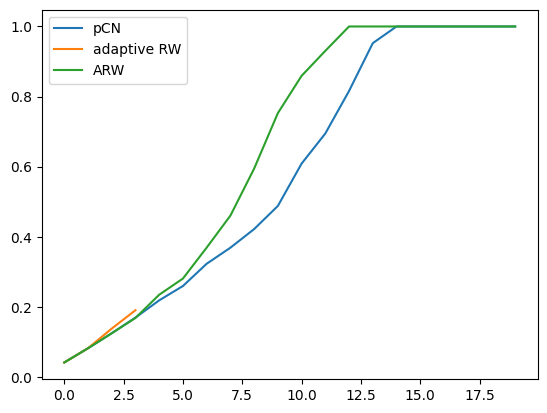

In [18]:
for proposal in idx_proposal:
    temperatures = np.mean(np.array([PKLs[idx]['res'][6] for idx in idx_proposal[proposal]]).squeeze(axis=0), axis=0)
    plt.plot(temperatures, label=proposal)
plt.legend()


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def plot_3D(x, y, arr):
    # Assume arr is your n x n array
    X, Y = np.meshgrid(x, y)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface
    ax.plot_surface(X, Y, arr, cmap='viridis')  # you can change the colormap
    ax.set_xlabel(r'$\rho$ axis')
    ax.set_ylabel(r'$\tau$ axis')
    ax.set_zlabel('Z axis (array values)')
    ax.view_init(elev=30, azim=135)

    plt.show()


def plot_contour2D(x, y, arr):
    X, Y = np.meshgrid(x, y)

    plt.figure()
    cf = plt.contourf(X, Y, arr, levels=20, cmap='viridis')
    plt.xlabel(r'$\tau$ axis')
    plt.ylabel(r'$\rho$ axis')
    plt.title('ESJD 2D Filled Contour Plot')
    plt.colorbar(cf)  # Show color scale
    plt.show()


plt.rcParams.update({
    "text.usetex": False,
})

In [9]:
"""tau_grid = jnp.linspace(0.05, 4, 100)
rho_grid = jnp.linspace(0, 0.99, 100)


idx = idx_proposal["ARW"][0]
t = PKLs[idx]['res'][5].shape[1]
vals = np.array([PKLs[idx]['res'][5].mean(axis=0).reshape((t, rho_grid.shape[-1], tau_grid.shape[-1])) for idx in idx_proposal["ARW"]]).mean(axis=0)
for t in np.arange(0, vals.shape[0], 1):
    print(rf"$\lambda_{t}:{PKLs[idx]['res'][6][:,t].mean()}")
    arr = vals[t]
    plot_contour2D(tau_grid, rho_grid,arr)
    plt.clf()"""

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_669628/820219913.py:1: SyntaxWarning: invalid escape sequence '\l'
  """tau_grid = jnp.linspace(0.05, 4, 100)


'tau_grid = jnp.linspace(0.05, 4, 100)\nrho_grid = jnp.linspace(0, 0.99, 100)\n\n\nidx = idx_proposal["ARW"][0]\nt = PKLs[idx][\'res\'][5].shape[1]\nvals = np.array([PKLs[idx][\'res\'][5].mean(axis=0).reshape((t, rho_grid.shape[-1], tau_grid.shape[-1])) for idx in idx_proposal["ARW"]]).mean(axis=0)\nfor t in np.arange(0, vals.shape[0], 1):\n    print(rf"$\\lambda_{t}:{PKLs[idx][\'res\'][6][:,t].mean()}")\n    arr = vals[t]\n    plot_contour2D(tau_grid, rho_grid,arr)\n    plt.clf()'

In [20]:
idx_temp_1 = {'adaptive RW': 7, 'pCN': 7, 'ARW': 7}
for proposal in idx_proposal:
    plt.hist(np.array([PKLs[idx]['res'][0][0, idx_temp_1[proposal]+1, 0, ..., 0].reshape(-1) for idx in idx_proposal[proposal]]).reshape(-1), label=proposal, alpha=1.0, density=True,histtype='step')
plt.legend()

TypeError: 'NoneType' object is not subscriptable

In [23]:
PKLs[0]['res']

(None,
 None,
 None,
 Array([[[0.7964],
         [0.3455],
         [0.403 ],
         [0.432 ],
         [0.528 ],
         [0.7485],
         [0.9214],
         [0.4895],
         [0.528 ],
         [0.5376],
         [0.547 ],
         [0.4797],
         [0.4895],
         [0.509 ],
         [0.5566],
         [0.5757],
         [0.5947],
         [0.6333],
         [0.6523],
         [0.691 ]]], dtype=float16),
 None,
 Array([[[3346.  , 3326.  , 3310.  , ..., 2686.  , 2698.  , 2644.  ],
         [  81.7 ,   81.7 ,   81.8 , ...,  207.8 ,  207.4 ,  208.  ],
         [  77.94,   81.25,   84.2 , ...,   89.3 ,   89.2 ,   88.44],
         ...,
         [   0.  ,    0.  ,    0.  , ...,    0.  ,    0.  ,    0.  ],
         [   0.  ,    0.  ,    0.  , ...,    0.  ,    0.  ,    0.  ],
         [   0.  ,    0.  ,    0.  , ...,    0.  ,    0.  ,    0.  ]]],      dtype=float16),
 Array([[0.0409375 , 0.08152252, 0.12434837, 0.16900826, 0.218294  ,
         0.25919238, 0.32271832, 0.36855865, 0.4

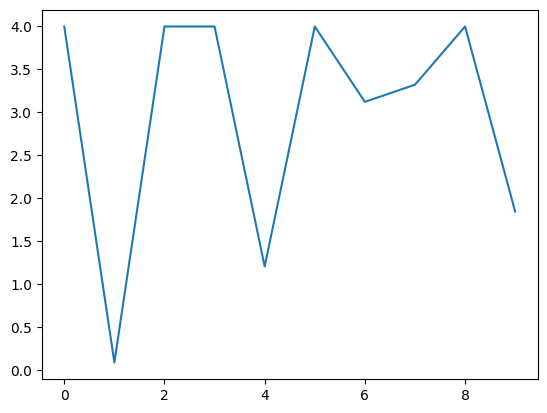

In [10]:
plt.plot(np.mean(np.array([PKLs[idx]['res'][3] for idx in idx_proposal['adaptive RW']]).squeeze(axis=0), axis=0))